"Notebook is designed for Google Colab. Mount Google Drive and place the dataset files in a folder called archive in My Drive."

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd

# Base path — folder is called "archive" in My Drive
base = '/content/drive/My Drive/archive/'

orders    = pd.read_csv(base + 'olist_orders_dataset.csv')
reviews   = pd.read_csv(base + 'olist_order_reviews_dataset.csv')
customers = pd.read_csv(base + 'olist_customers_dataset.csv')
products  = pd.read_csv(base + 'olist_products_dataset.csv')
translation = pd.read_csv(base + 'product_category_name_translation.csv')

# Sanity check
print("Orders:", orders.shape)
print("Reviews:", reviews.shape)
print("Customers:", customers.shape)
print("Products:", products.shape)
print("Translation:", translation.shape)

Mounted at /content/drive
Orders: (99441, 8)
Reviews: (99224, 7)
Customers: (99441, 5)
Products: (32951, 9)
Translation: (71, 2)


Task 1

In [2]:
# Some orders have multiple reviews — keep only the most recent one
reviews_deduped = (
    reviews
    .sort_values('review_creation_date', ascending=False)
    .drop_duplicates(subset='order_id', keep='first')
)

print(f"Reviews original:    {len(reviews)}")
print(f"Reviews deduplicated: {len(reviews_deduped)}")

Reviews original:    99224
Reviews deduplicated: 98673


In [3]:
# Step 1: Join reviews onto orders
df = orders.merge(reviews_deduped, on='order_id', how='left')

# Step 2: Join customers onto that result
df = df.merge(customers, on='customer_id', how='left')

# Verification checks
print("Orders rows:  ", len(orders))
print("Merged rows:  ", len(df))
print("Duplicate order_ids:", df['order_id'].duplicated().sum())

Orders rows:   99441
Merged rows:   99441
Duplicate order_ids: 0


In [4]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_summary = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
}).query('`Missing Count` > 0').sort_values('Missing %', ascending=False)

print(missing_summary)

                               Missing Count  Missing %
review_comment_title                   87889      88.38
review_comment_message                 58667      59.00
order_delivered_customer_date           2965       2.98
order_delivered_carrier_date            1783       1.79
review_score                             768       0.77
review_creation_date                     768       0.77
review_id                                768       0.77
review_answer_timestamp                  768       0.77
order_approved_at                        160       0.16


In [5]:
print("All order statuses:")
print(df['order_status'].value_counts())
print()

# Exclude canceled, unavailable, and undelivered orders
df_delivered = df[df['order_status'] == 'delivered'].copy()

print(f"Total orders:     {len(df)}")
print(f"Delivered orders: {len(df_delivered)}")
print(f"Excluded orders:  {len(df) - len(df_delivered)}")

print("\n Task 1 Complete! Master dataset ready.")

All order statuses:
order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

Total orders:     99441
Delivered orders: 96478
Excluded orders:  2963

 Task 1 Complete! Master dataset ready.


Task 2 — The Delay Calculator

Convert Date Columns to DateTime

In [6]:
# Convert all date columns to proper datetime format
date_cols = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

for col in date_cols:
    df_delivered[col] = pd.to_datetime(df_delivered[col])

print(" Date columns converted")
print(df_delivered[date_cols].dtypes)

 Date columns converted
order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
dtype: object


Calculate Days Difference

In [7]:
# Positive = delivered BEFORE estimate (good)
# Negative = delivered AFTER estimate (late)

df_delivered['days_difference'] = (
    df_delivered['order_estimated_delivery_date'] -
    df_delivered['order_delivered_customer_date']
).dt.days

print("Days Difference Summary:")
print(df_delivered['days_difference'].describe().round(2))

Days Difference Summary:
count    96470.00
mean        10.88
std         10.18
min       -189.00
25%          6.00
50%         11.00
75%         16.00
max        146.00
Name: days_difference, dtype: float64


Classify Orders

In [8]:
def classify_delivery(days):
    if days >= 0:
        return 'On Time'
    elif days >= -5:
        return 'Late'
    else:
        return 'Super Late'

df_delivered['delivery_status'] = df_delivered['days_difference'].apply(classify_delivery)

# See the breakdown
status_counts = df_delivered['delivery_status'].value_counts()
status_pct    = df_delivered['delivery_status'].value_counts(normalize=True).mul(100).round(2)

summary = pd.DataFrame({
    'Count': status_counts,
    '% of Orders': status_pct
})

print(summary)

                 Count  % of Orders
delivery_status                    
On Time          88644        91.88
Super Late        4219         4.37
Late              3615         3.75


Visualize the Breakdown

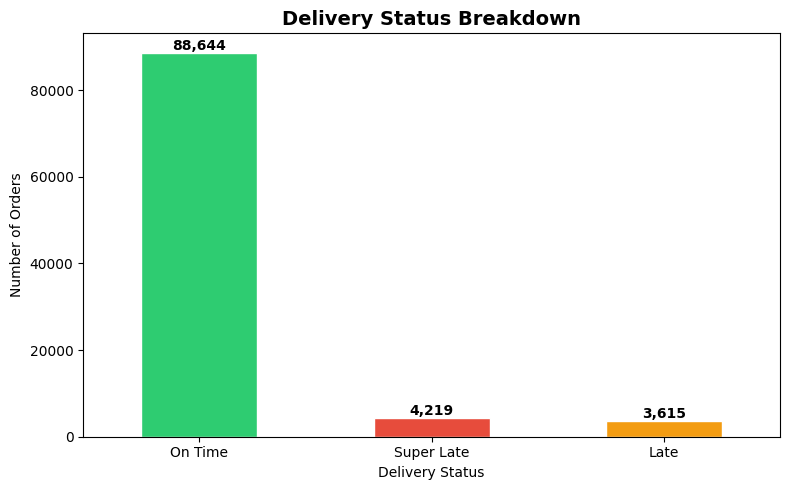


 Task 2 Complete!


In [9]:
import matplotlib.pyplot as plt

colors = {
    'On Time'   : '#2ecc71',
    'Late'      : '#f39c12',
    'Super Late': '#e74c3c'
}

ax = status_counts.plot(
    kind='bar',
    color=[colors[s] for s in status_counts.index],
    figsize=(8, 5),
    edgecolor='white'
)

ax.set_title('Delivery Status Breakdown', fontsize=14, fontweight='bold')
ax.set_xlabel('Delivery Status')
ax.set_ylabel('Number of Orders')
ax.set_xticklabels(status_counts.index, rotation=0)

# Add count labels on top of bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}',
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

print("\n Task 2 Complete!")

Task 3 — The Geographic Heatmap

Late Delivery Rate Per State

In [10]:
# Calculate delivery status counts per state
state_summary = df_delivered.groupby('customer_state').agg(
    total_orders    = ('order_id', 'count'),
    late_orders     = ('delivery_status', lambda x: (x != 'On Time').sum()),
    super_late      = ('delivery_status', lambda x: (x == 'Super Late').sum()),
    avg_days_diff   = ('days_difference', 'mean')
).reset_index()

# Calculate late percentage
state_summary['late_pct'] = (
    state_summary['late_orders'] / state_summary['total_orders'] * 100
).round(2)

# Sort by worst performing states
state_summary = state_summary.sort_values('late_pct', ascending=False)

print("Top 10 Worst States for Late Deliveries:")
print(state_summary.head(10).to_string(index=False))

Top 10 Worst States for Late Deliveries:
customer_state  total_orders  late_orders  super_late  avg_days_diff  late_pct
            AL           397           95          57       7.707809     23.93
            MA           717          141          81       8.571827     19.67
            PI           476           76          42      10.306723     15.97
            CE          1279          196         142       9.804535     15.32
            SE           335           51          41       9.020896     15.22
            BA          3256          457         278       9.794533     14.04
            RJ         12350         1664        1122      10.761215     13.47
            TO           274           35          19      11.131387     12.77
            PA           946          117          85      13.066596     12.37
            ES          1995          244         142       9.496241     12.23


Bar Chart (Worst States)

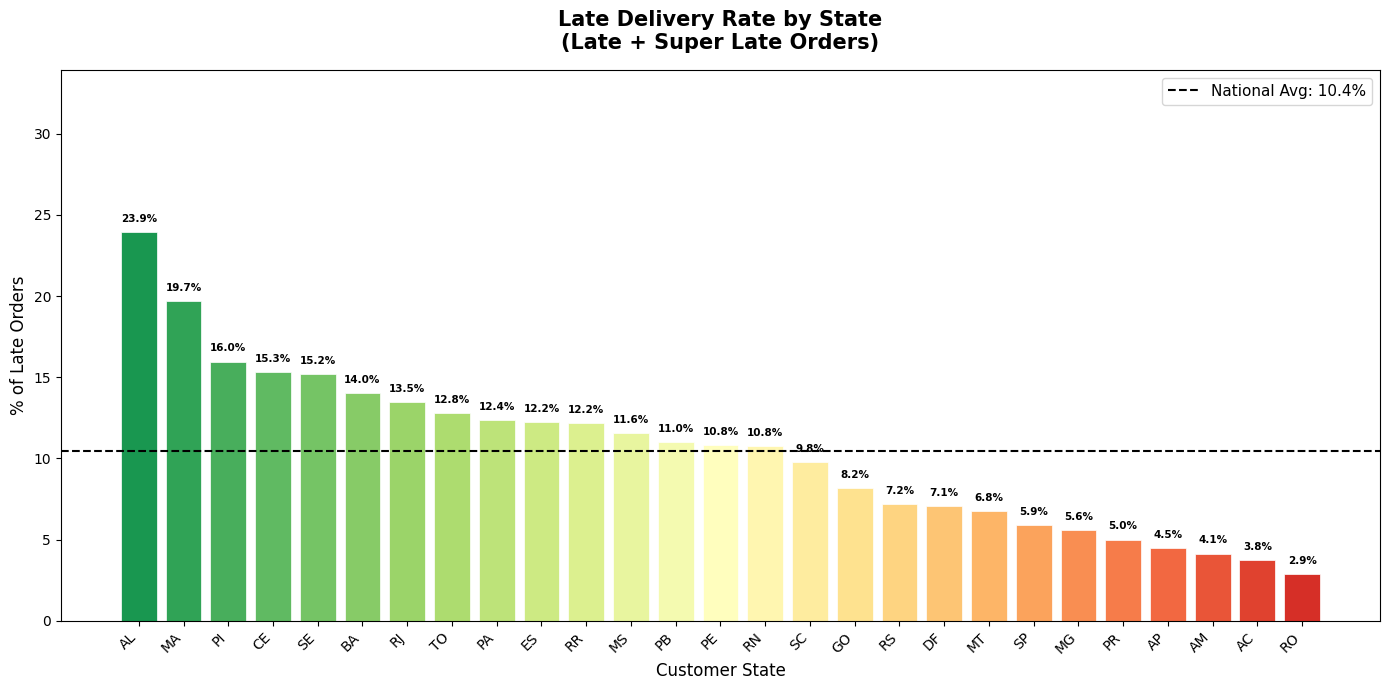

In [11]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

fig, ax = plt.subplots(figsize=(14, 7))

# Color bars by severity
colors = cm.RdYlGn_r(np.linspace(0.1, 0.9, len(state_summary)))

bars = ax.bar(
    state_summary['customer_state'],
    state_summary['late_pct'],
    color=colors,
    edgecolor='white',
    linewidth=0.5
)

# Add a reference line for the national average
national_avg = state_summary['late_pct'].mean()
ax.axhline(national_avg, color='black', linestyle='--', linewidth=1.5,
           label=f'National Avg: {national_avg:.1f}%')

ax.set_title('Late Delivery Rate by State\n(Late + Super Late Orders)',
             fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('Customer State', fontsize=12)
ax.set_ylabel('% of Late Orders', fontsize=12)
ax.legend(fontsize=11)
ax.set_ylim(0, state_summary['late_pct'].max() + 10)

# Add percentage labels on bars
for bar, val in zip(bars, state_summary['late_pct']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=7.5, fontweight='bold')

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Choropleth Map of Brazil

In [12]:
# Install plotly if not already available
!pip install plotly -q

import plotly.express as px

# Brazilian state abbreviations match plotly's built-in Brazil geojson
fig = px.choropleth(
    state_summary,
    locations='customer_state',
    locationmode='geojson-id',
    geojson='https://raw.githubusercontent.com/codeforamerica/click_that_hood/master/public/data/brazil-states.geojson',
    featureidkey='properties.sigla',
    color='late_pct',
    color_continuous_scale='RdYlGn_r',
    hover_data={
        'customer_state' : True,
        'total_orders'   : True,
        'late_pct'       : ':.2f',
        'avg_days_diff'  : ':.1f'
    },
    labels={
        'late_pct'     : 'Late %',
        'avg_days_diff': 'Avg Days Early/Late',
        'total_orders' : 'Total Orders'
    },
    title='Late Delivery Rate by Brazilian State'
)

fig.update_geos(fitbounds='locations', visible=False)
fig.update_layout(margin={"r":0,"t":40,"l":0,"b":0}, height=600)
fig.show()

Remote States Insight

In [13]:
# States considered "remote" (far from São Paulo distribution hub)
remote_states = ['AM', 'PA', 'RR', 'AP', 'AC', 'RO', 'TO', 'MA', 'PI', 'AL', 'SE']

state_summary['region_type'] = state_summary['customer_state'].apply(
    lambda x: 'Remote' if x in remote_states else 'Central'
)

region_compare = state_summary.groupby('region_type').agg(
    avg_late_pct  = ('late_pct', 'mean'),
    total_orders  = ('total_orders', 'sum')
).round(2)

print("Remote vs Central States — Late Delivery Comparison:")
print(region_compare)
print()

remote_avg  = region_compare.loc['Remote', 'avg_late_pct']
central_avg = region_compare.loc['Central', 'avg_late_pct']
print(f"Remote states are {remote_avg - central_avg:.1f} percentage points worse than central states")
print("\n Task 3 Complete!")

Remote vs Central States — Late Delivery Comparison:
             avg_late_pct  total_orders
region_type                            
Central              9.67         92757
Remote              11.58          3721

Remote states are 1.9 percentage points worse than central states

 Task 3 Complete!


Task 4 — The Sentiment Correlation

Average Review Score by Delivery Status

In [14]:
# Average review score per delivery status
sentiment_summary = df_delivered.groupby('delivery_status').agg(
    avg_review_score = ('review_score', 'mean'),
    total_orders     = ('order_id', 'count')
).round(2).reset_index()

# Sort in logical order
order_map = {'On Time': 0, 'Late': 1, 'Super Late': 2}
sentiment_summary['sort_order'] = sentiment_summary['delivery_status'].map(order_map)
sentiment_summary = sentiment_summary.sort_values('sort_order').drop(columns='sort_order')

print("Average Review Score by Delivery Status:")
print(sentiment_summary.to_string(index=False))

Average Review Score by Delivery Status:
delivery_status  avg_review_score  total_orders
        On Time              4.29         88644
           Late              3.46          3615
     Super Late              1.79          4219


Bar Chart: Review Score vs Delivery Status

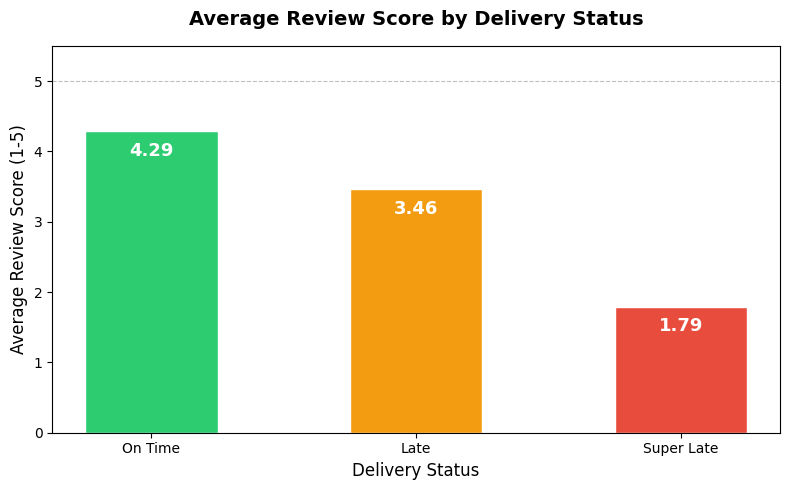

In [15]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(8, 5))

colors = ['#2ecc71', '#f39c12', '#e74c3c']
bars = ax.bar(
    sentiment_summary['delivery_status'],
    sentiment_summary['avg_review_score'],
    color=colors,
    edgecolor='white',
    width=0.5
)

# Add score labels on bars
for bar, val in zip(bars, sentiment_summary['avg_review_score']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() - 0.15,
            f'{val:.2f}', ha='center', va='top',
            fontsize=13, fontweight='bold', color='white')

ax.set_title('Average Review Score by Delivery Status',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Delivery Status', fontsize=12)
ax.set_ylabel('Average Review Score (1-5)', fontsize=12)
ax.set_ylim(0, 5.5)
ax.axhline(5, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)

plt.tight_layout()
plt.show()

Scatter Plot: Delay Days vs Review Score

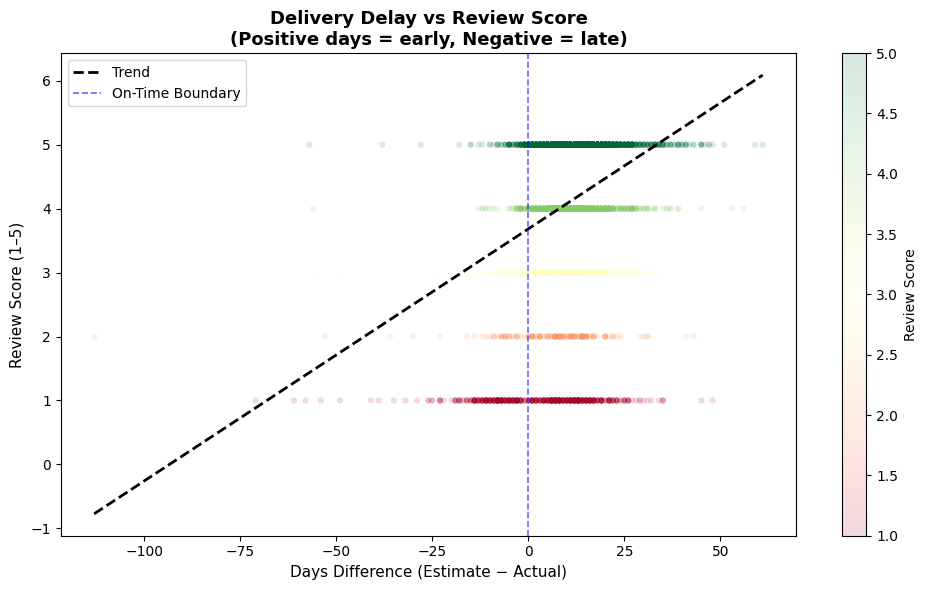

In [16]:
import matplotlib.pyplot as plt

# Sample to avoid overplotting (use all points if dataset is small)
sample = df_delivered[['days_difference', 'review_score']].dropna().sample(
    n=min(5000, len(df_delivered)), random_state=42
)

fig, ax = plt.subplots(figsize=(10, 6))

scatter = ax.scatter(
    sample['days_difference'],
    sample['review_score'],
    alpha=0.15,
    c=sample['review_score'],
    cmap='RdYlGn',
    edgecolors='none',
    s=20
)

# Trend line
z = np.polyfit(sample['days_difference'], sample['review_score'], 1)
p = np.poly1d(z)
x_line = np.linspace(sample['days_difference'].min(), sample['days_difference'].max(), 200)
ax.plot(x_line, p(x_line), color='black', linewidth=2, linestyle='--', label='Trend')

# Reference line at 0 (on-time boundary)
ax.axvline(0, color='blue', linestyle='--', linewidth=1.2, alpha=0.6, label='On-Time Boundary')

ax.set_title('Delivery Delay vs Review Score\n(Positive days = early, Negative = late)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Days Difference (Estimate − Actual)', fontsize=11)
ax.set_ylabel('Review Score (1–5)', fontsize=11)
ax.legend()
plt.colorbar(scatter, ax=ax, label='Review Score')
plt.tight_layout()
plt.show()

Correlation Score & Key Insight

In [17]:
from scipy import stats

# Drop rows missing either value
corr_df = df_delivered[['days_difference', 'review_score']].dropna()

correlation, p_value = stats.pearsonr(corr_df['days_difference'], corr_df['review_score'])

print("=" * 45)
print("      SENTIMENT CORRELATION RESULTS")
print("=" * 45)
print(f"Pearson Correlation:  {correlation:.4f}")
print(f"P-value:              {p_value:.2e}")
print()

if p_value < 0.05:
    print("Result is STATISTICALLY SIGNIFICANT")
else:
    print("Result is NOT statistically significant")

print()

# Pull the avg scores for the summary
on_time_score   = sentiment_summary.loc[sentiment_summary['delivery_status'] == 'On Time', 'avg_review_score'].values[0]
late_score      = sentiment_summary.loc[sentiment_summary['delivery_status'] == 'Late', 'avg_review_score'].values[0]
super_late_score= sentiment_summary.loc[sentiment_summary['delivery_status'] == 'Super Late', 'avg_review_score'].values[0]

print(f"On Time orders avg score:    {on_time_score}")
print(f"Late orders avg score:       {late_score}")
print(f"Super Late orders avg score: {super_late_score}")
print()
print(f" Super Late orders score {on_time_score - super_late_score:.2f} points lower than On Time")
print("\n Task 4 Complete!")

      SENTIMENT CORRELATION RESULTS
Pearson Correlation:  0.2673
P-value:              0.00e+00

Result is STATISTICALLY SIGNIFICANT

On Time orders avg score:    4.29
Late orders avg score:       3.46
Super Late orders avg score: 1.79

 Super Late orders score 2.50 points lower than On Time

 Task 4 Complete!


Bonus Task — Translate Product Categories to English

Join Products & Translation to Master Dataset

In [18]:
# First peek at the translation file
print("Translation file sample:")
print(translation.head())
print()
print("Products file sample:")
print(products[['product_id', 'product_category_name']].head())

Translation file sample:
    product_category_name product_category_name_english
0            beleza_saude                 health_beauty
1  informatica_acessorios         computers_accessories
2              automotivo                          auto
3         cama_mesa_banho                bed_bath_table
4        moveis_decoracao               furniture_decor

Products file sample:
                         product_id  product_category_name
0  1e9e8ef04dbcff4541ed26657ea517e5             perfumaria
1  3aa071139cb16b67ca9e5dea641aaa2f                  artes
2  96bd76ec8810374ed1b65e291975717f          esporte_lazer
3  cef67bcfe19066a932b7673e239eb23d                  bebes
4  9dc1a7de274444849c219cff195d0b71  utilidades_domesticas


Load Order Items & Merge Products

In [19]:
# We need order_items to link order_id to product_id
order_items = pd.read_csv(base + 'olist_order_items_dataset.csv')

print("Order items shape:", order_items.shape)
print(order_items.head(3))

Order items shape: (112650, 7)
                           order_id  order_item_id  \
0  00010242fe8c5a6d1ba2dd792cb16214              1   
1  00018f77f2f0320c557190d7a144bdd3              1   
2  000229ec398224ef6ca0657da4fc703e              1   

                         product_id                         seller_id  \
0  4244733e06e7ecb4970a6e2683c13e61  48436dade18ac8b2bce089ec2a041202   
1  e5f2d52b802189ee658865ca93d83a8f  dd7ddc04e1b6c2c614352b383efe2d36   
2  c777355d18b72b67abbeef9df44fd0fd  5b51032eddd242adc84c38acab88f23d   

   shipping_limit_date  price  freight_value  
0  2017-09-19 09:45:35   58.9          13.29  
1  2017-05-03 11:05:13  239.9          19.93  
2  2018-01-18 14:48:30  199.0          17.87  


Join Everything Together

In [20]:
# Step 1: Join translation onto products to get English names
products_translated = products.merge(
    translation,
    on='product_category_name',
    how='left'
)

# Step 2: Keep only what we need
products_translated = products_translated[['product_id', 'product_category_name',
                                           'product_category_name_english']]

# Step 3: Join order_items to get product_id per order
order_items_slim = order_items[['order_id', 'product_id']].drop_duplicates(subset='order_id')

# Step 4: Join products onto order_items
order_items_with_products = order_items_slim.merge(
    products_translated,
    on='product_id',
    how='left'
)

# Step 5: Join onto master delivered dataset
df_final = df_delivered.merge(
    order_items_with_products,
    on='order_id',
    how='left'
)

print("Final dataset shape:", df_final.shape)
print("Duplicate order_ids:", df_final['order_id'].duplicated().sum())
print()
print("Sample of English categories:")
print(df_final[['product_category_name', 'product_category_name_english']].dropna().head(10))

Final dataset shape: (96478, 23)
Duplicate order_ids: 0

Sample of English categories:
   product_category_name product_category_name_english
0  utilidades_domesticas                    housewares
1             perfumaria                     perfumery
2             automotivo                          auto
3               pet_shop                      pet_shop
4              papelaria                    stationery
5             automotivo                          auto
6             automotivo                          auto
7       moveis_decoracao               furniture_decor
8      moveis_escritorio              office_furniture
9     ferramentas_jardim                  garden_tools


Handle Missing Translations

In [21]:
# Check how many are untranslated
missing_translation = df_final['product_category_name_english'].isnull().sum()
total = len(df_final)

print(f"Missing translations: {missing_translation} ({missing_translation/total*100:.1f}%)")

# Fill any untranslated ones with the Portuguese name as fallback
df_final['product_category_name_english'] = (
    df_final['product_category_name_english']
    .fillna(df_final['product_category_name'])
    .fillna('Unknown')
)

print("All categories now have a name")
print()
print("Sample categories:")
print(df_final['product_category_name_english'].value_counts().head(10))

Missing translations: 1378 (1.4%)
All categories now have a name

Sample categories:
product_category_name_english
bed_bath_table           9167
health_beauty            8608
sports_leisure           7491
computers_accessories    6501
furniture_decor          6213
housewares               5688
watches_gifts            5472
telephony                4076
auto                     3793
toys                     3779
Name: count, dtype: int64


Late Rate by Product Category

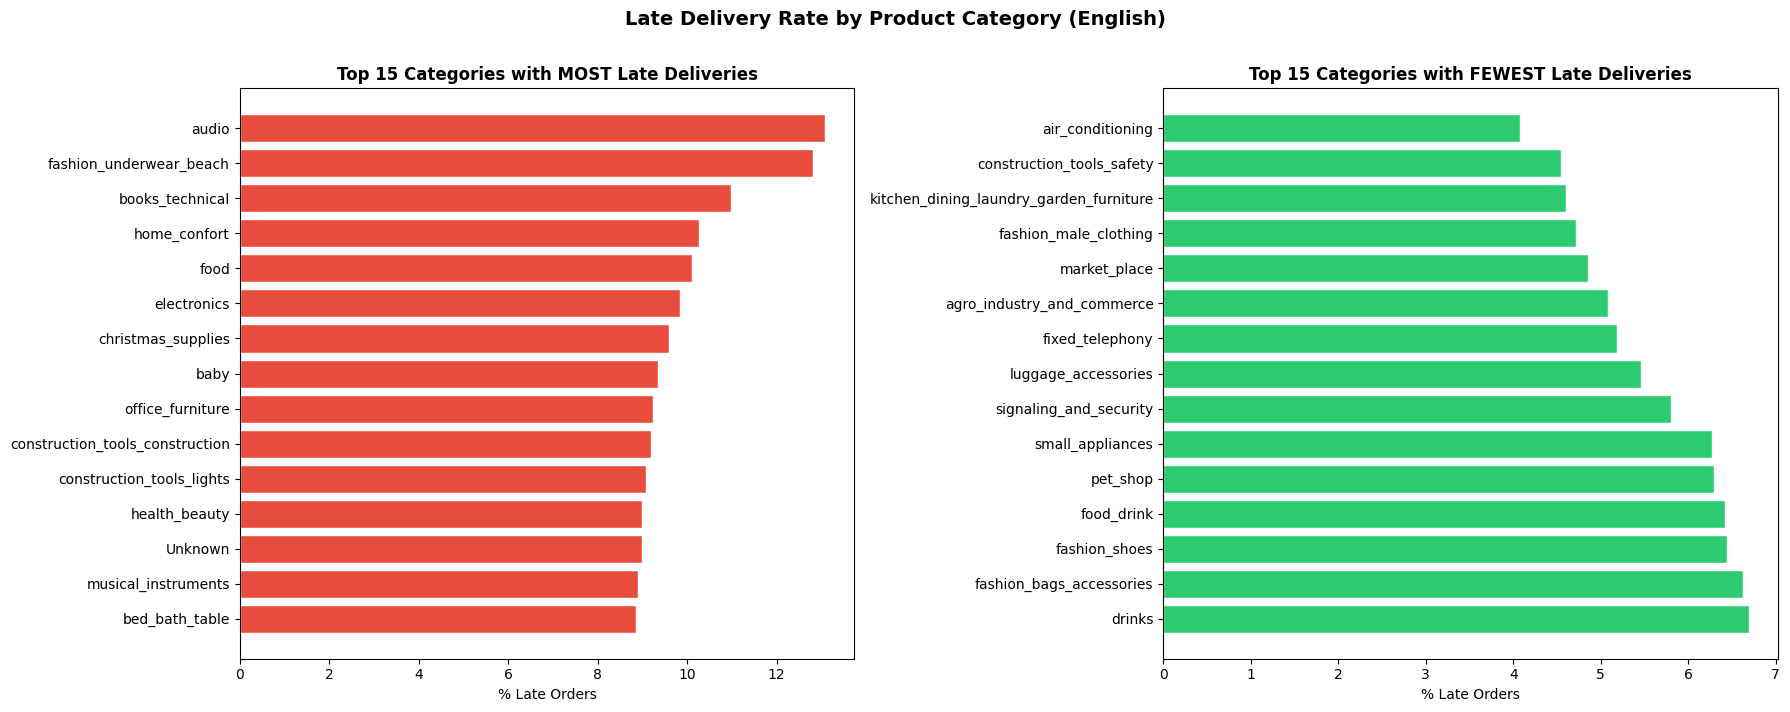


 Bonus Task Complete!


In [22]:
import matplotlib.pyplot as plt

# Late delivery rate per category (min 100 orders to be meaningful)
category_summary = df_final.groupby('product_category_name_english').agg(
    total_orders  = ('order_id', 'count'),
    late_orders   = ('delivery_status', lambda x: (x != 'On Time').sum()),
    avg_score     = ('review_score', 'mean')
).reset_index()

category_summary['late_pct'] = (
    category_summary['late_orders'] / category_summary['total_orders'] * 100
).round(2)

# Filter to categories with enough orders
category_summary = category_summary[category_summary['total_orders'] >= 100]

# Top 15 worst categories
top15_worst = category_summary.sort_values('late_pct', ascending=False).head(15)
top15_best  = category_summary.sort_values('late_pct', ascending=True).head(15)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Worst categories
axes[0].barh(top15_worst['product_category_name_english'],
             top15_worst['late_pct'], color='#e74c3c', edgecolor='white')
axes[0].set_title('Top 15 Categories with MOST Late Deliveries',
                  fontweight='bold', fontsize=12)
axes[0].set_xlabel('% Late Orders')
axes[0].invert_yaxis()

# Best categories
axes[1].barh(top15_best['product_category_name_english'],
             top15_best['late_pct'], color='#2ecc71', edgecolor='white')
axes[1].set_title('Top 15 Categories with FEWEST Late Deliveries',
                  fontweight='bold', fontsize=12)
axes[1].set_xlabel('% Late Orders')
axes[1].invert_yaxis()

plt.suptitle('Late Delivery Rate by Product Category (English)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print("\n Bonus Task Complete!")

In [23]:
# This is your FINAL clean dataset for the dashboard
print("=" * 40)
print("   FINAL DATASET SUMMARY")
print("=" * 40)
print(f"Total rows:        {len(df_final):,}")
print(f"Total columns:     {df_final.shape[1]}")
print(f"Columns: {df_final.columns.tolist()}")
print()
print("Delivery Status Breakdown:")
print(df_final['delivery_status'].value_counts())
print()
print("df_final is ready for your dashboard!")

   FINAL DATASET SUMMARY
Total rows:        96,478
Total columns:     23
Columns: ['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'review_id', 'review_score', 'review_comment_title', 'review_comment_message', 'review_creation_date', 'review_answer_timestamp', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state', 'days_difference', 'delivery_status', 'product_id', 'product_category_name', 'product_category_name_english']

Delivery Status Breakdown:
delivery_status
On Time       88644
Super Late     4219
Late           3615
Name: count, dtype: int64

df_final is ready for your dashboard!


Candidate's Choice — "The Promise Score"


Calculate the Promise Gap

In [24]:
# How far in advance was the delivery estimate made?
# This tells us if the system was "guessing wildly" or making informed estimates

df_final['promise_made_days'] = (
    df_final['order_estimated_delivery_date'] -
    df_final['order_purchase_timestamp']
).dt.days

# The actual delivery time (purchase to delivery)
df_final['actual_delivery_days'] = (
    df_final['order_delivered_customer_date'] -
    df_final['order_purchase_timestamp']
).dt.days

# The "lie gap" — how many days off was the promise?
# Negative = system over-promised (told customer sooner than reality)
# Positive = system under-promised (delivered earlier than told)
df_final['promise_gap'] = (
    df_final['actual_delivery_days'] -
    df_final['promise_made_days']
)

print("Promise Gap Summary (negative = over-promised):")
print(df_final['promise_gap'].describe().round(2))
print()
print(f"% of orders where system OVER-promised: "
      f"{(df_final['promise_gap'] > 0).sum() / len(df_final) * 100:.1f}%")

Promise Gap Summary (negative = over-promised):
count    96470.00
mean       -11.28
std         10.19
min       -146.00
25%        -16.00
50%        -12.00
75%         -7.00
max        189.00
Name: promise_gap, dtype: float64

% of orders where system OVER-promised: 7.6%


Promise Score Per State

In [25]:
# Calculate per state:
# 1. Average promise gap (how badly they over-promise)
# 2. % of orders where system over-promised
# 3. Average days promised vs average days actual

state_promise = df_final.groupby('customer_state').agg(
    total_orders        = ('order_id', 'count'),
    avg_promise_gap     = ('promise_gap', 'mean'),
    avg_promised_days   = ('promise_made_days', 'mean'),
    avg_actual_days     = ('actual_delivery_days', 'mean'),
    over_promised_pct   = ('promise_gap', lambda x: (x > 0).sum() / len(x) * 100)
).round(2).reset_index()

# Promise Score: 100 = perfect, lower = worse
# Penalizes states where the system consistently over-promises
state_promise['promise_score'] = (
    100 - state_promise['over_promised_pct']
).round(1)

state_promise = state_promise.sort_values('promise_score', ascending=True)

print("Top 10 States with WORST Promise Scores:")
print(state_promise.head(10).to_string(index=False))
print()
print("Top 5 States with BEST Promise Scores:")
print(state_promise.tail(5).to_string(index=False))

Top 10 States with WORST Promise Scores:
customer_state  total_orders  avg_promise_gap  avg_promised_days  avg_actual_days  over_promised_pct  promise_score
            AL           397            -8.17              32.21            24.04              22.92           77.1
            MA           717            -8.97              30.08            21.12              18.83           81.2
            SE           335            -9.45              30.48            21.03              15.22           84.8
            PI           476           -10.71              29.70            18.99              15.13           84.9
            CE          1279           -10.19              31.00            20.82              14.86           85.1
            BA          3256           -10.21              29.07            18.87              13.21           86.8
            RJ         12350           -11.15              26.00            14.85              12.91           87.1
            TO           274   

Visualize the Promise Score

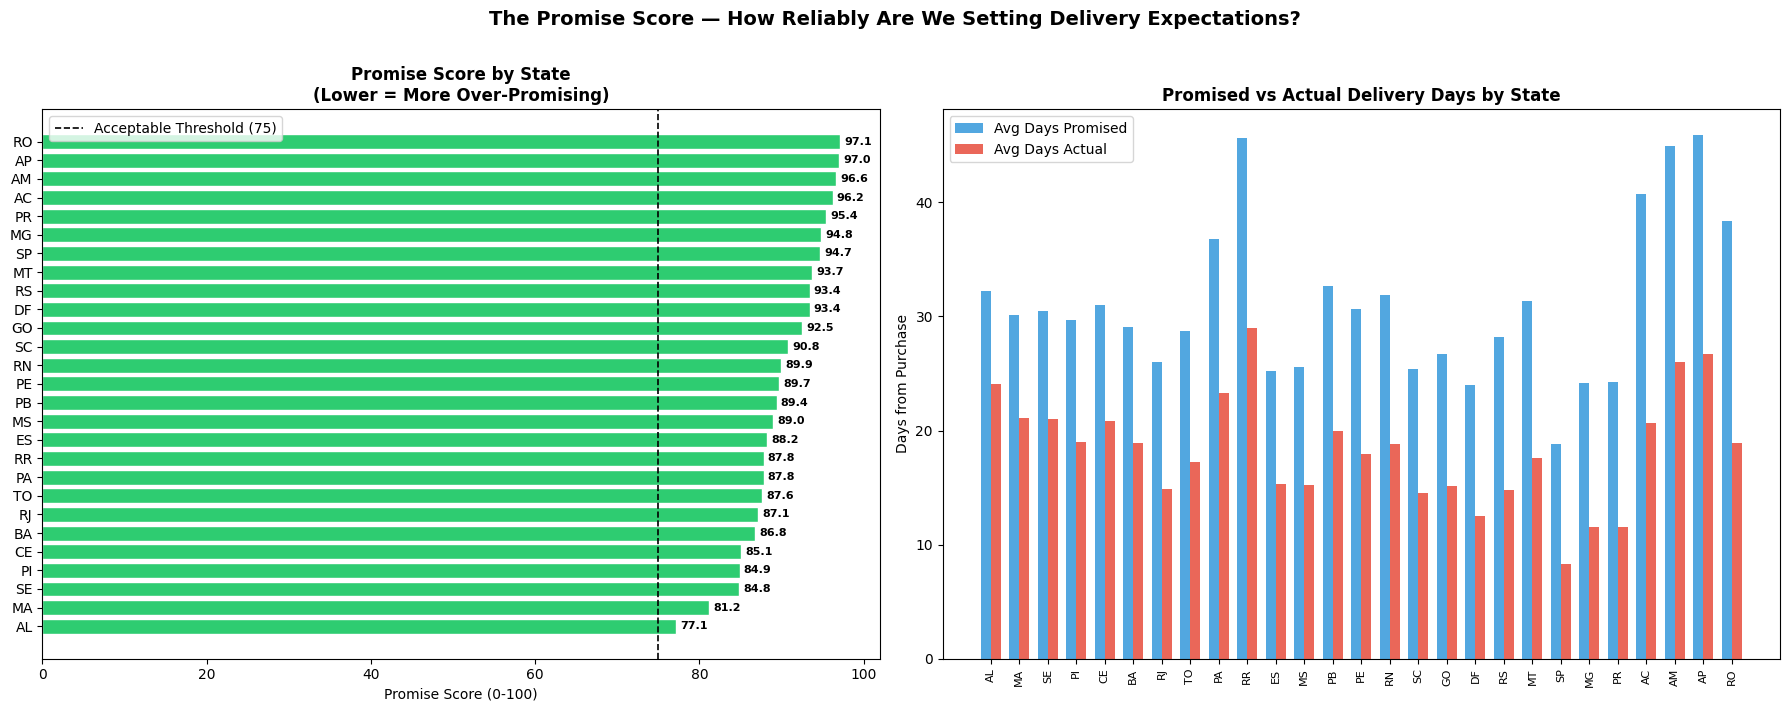

In [26]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# --- Chart 1: Promise Score per State ---
colors = ['#e74c3c' if s < 50 else '#f39c12' if s < 75 else '#2ecc71'
          for s in state_promise['promise_score']]

bars = axes[0].barh(
    state_promise['customer_state'],
    state_promise['promise_score'],
    color=colors,
    edgecolor='white'
)

axes[0].axvline(75, color='black', linestyle='--', linewidth=1.2,
                label='Acceptable Threshold (75)')
axes[0].set_title('Promise Score by State\n(Lower = More Over-Promising)',
                  fontweight='bold', fontsize=12)
axes[0].set_xlabel('Promise Score (0-100)')
axes[0].legend()

# Add score labels
for bar, val in zip(bars, state_promise['promise_score']):
    axes[0].text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                f'{val}', va='center', fontsize=8, fontweight='bold')

# --- Chart 2: Promised vs Actual Delivery Days ---
x = np.arange(len(state_promise))
width = 0.35

axes[1].bar(x - width/2, state_promise['avg_promised_days'],
            width, label='Avg Days Promised', color='#3498db', alpha=0.85)
axes[1].bar(x + width/2, state_promise['avg_actual_days'],
            width, label='Avg Days Actual', color='#e74c3c', alpha=0.85)

axes[1].set_xticks(x)
axes[1].set_xticklabels(state_promise['customer_state'], rotation=90, fontsize=8)
axes[1].set_title('Promised vs Actual Delivery Days by State',
                  fontweight='bold', fontsize=12)
axes[1].set_ylabel('Days from Purchase')
axes[1].legend()

plt.suptitle("The Promise Score — How Reliably Are We Setting Delivery Expectations?",
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

Key Business Insight

In [27]:
worst_state  = state_promise.iloc[0]
best_state   = state_promise.iloc[-1]
national_avg = state_promise['promise_score'].mean()

print("=" * 50)
print("     THE PROMISE SCORE — KEY FINDINGS")
print("=" * 50)
print(f"National Average Promise Score: {national_avg:.1f}/100")
print()
print(f"Worst State: {worst_state['customer_state']}")
print(f"   Promise Score:        {worst_state['promise_score']}")
print(f"   Avg Days Promised:    {worst_state['avg_promised_days']}")
print(f"   Avg Days Actual:      {worst_state['avg_actual_days']}")
print(f"   Over-promised:        {worst_state['over_promised_pct']}% of orders")
print()
print(f"Best State:  {best_state['customer_state']}")
print(f"   Promise Score:        {best_state['promise_score']}")
print(f"   Avg Days Promised:    {best_state['avg_promised_days']}")
print(f"   Avg Days Actual:      {best_state['avg_actual_days']}")
print(f"   Over-promised:        {best_state['over_promised_pct']}% of orders")
print()
print("Business Recommendation:")
print(f"   Recalibrate estimated delivery dates for states")
print(f"   scoring below 75 — especially {worst_state['customer_state']}.")
print(f"   Simply adding a {abs(worst_state['avg_promise_gap']):.0f}-day buffer to delivery estimates")
print(f"   in {worst_state['customer_state']} would significantly reduce bad reviews.")
print()
print("Candidate's Choice Complete!")

     THE PROMISE SCORE — KEY FINDINGS
National Average Promise Score: 90.1/100

Worst State: AL
   Promise Score:        77.1
   Avg Days Promised:    32.21
   Avg Days Actual:      24.04
   Over-promised:        22.92% of orders

Best State:  RO
   Promise Score:        97.1
   Avg Days Promised:    38.39
   Avg Days Actual:      18.91
   Over-promised:        2.88% of orders

Business Recommendation:
   Recalibrate estimated delivery dates for states
   scoring below 75 — especially AL.
   Simply adding a 8-day buffer to delivery estimates
   in AL would significantly reduce bad reviews.

Candidate's Choice Complete!


In [28]:
# Save final clean dataset back to your Drive
output_path = '/content/drive/My Drive/archive/df_final_clean.csv'

df_final.to_csv(output_path, index=False)

print("Dataset exported successfully!")
print(f"Location: {output_path}")
print(f"Rows: {len(df_final):,}")
print(f"Columns: {df_final.shape[1]}")
print()
print("Columns exported:")
for col in df_final.columns:
    print(f"  - {col}")

Dataset exported successfully!
Location: /content/drive/My Drive/archive/df_final_clean.csv
Rows: 96,478
Columns: 26

Columns exported:
  - order_id
  - customer_id
  - order_status
  - order_purchase_timestamp
  - order_approved_at
  - order_delivered_carrier_date
  - order_delivered_customer_date
  - order_estimated_delivery_date
  - review_id
  - review_score
  - review_comment_title
  - review_comment_message
  - review_creation_date
  - review_answer_timestamp
  - customer_unique_id
  - customer_zip_code_prefix
  - customer_city
  - customer_state
  - days_difference
  - delivery_status
  - product_id
  - product_category_name
  - product_category_name_english
  - promise_made_days
  - actual_delivery_days
  - promise_gap
